# Project #4 - Interpret: NRI Sensitivity Analysis
## Group M: Jacob Kosmicki, Jacob Lamoureux, Eli Speth


In [42]:
## Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## 1. Data Loading
Load the NRI Census Tract data, SVI data, and NRI metadata for both Florida and Alaska.


In [43]:
## Load NRI Census Tract data for each state
fl_nri = pd.read_csv("NRI_Table_CensusTracts_Florida.csv", low_memory=False)
ak_nri = pd.read_csv("NRI_Table_CensusTracts_Alaska.csv", low_memory=False)

## Load SVI data for each state
fl_svi = pd.read_csv("Florida.csv", low_memory=False)
ak_svi = pd.read_csv("Alaska.csv", low_memory=False)

## Load NRI metadata
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")
nri_hazards = pd.read_csv("NRI_HazardInfo.csv")

## Load the NRI shapefile for mapping
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")

print(f"Florida NRI: {fl_nri.shape[0]} tracts, {fl_nri.shape[1]} columns")
print(f"Alaska NRI:  {ak_nri.shape[0]} tracts, {ak_nri.shape[1]} columns")
print(f"Florida SVI: {fl_svi.shape[0]} rows, {fl_svi.shape[1]} columns")
print(f"Alaska SVI:  {ak_svi.shape[0]} rows, {ak_svi.shape[1]} columns")
print(f"Shapefile:   {tracts.shape[0]} tracts")

Florida NRI: 5114 tracts, 467 columns
Alaska NRI:  177 tracts, 467 columns
Florida SVI: 5122 rows, 158 columns
Alaska SVI:  177 rows, 158 columns
Shapefile:   85154 tracts


## 2. Data Cleaning
Check for missing values, replace -9999 placeholders with NaN, and verify data types.

In [44]:
## Check for NAs in the NRI data
print("Florida NRI missing values (top 10 columns with NAs):")
fl_missing = fl_nri.isnull().sum()
fl_missing = fl_missing[fl_missing > 0].sort_values(ascending=False)
print(fl_missing.head(10))

print("\nAlaska NRI missing values (top 10 columns with NAs):")
ak_missing = ak_nri.isnull().sum()
ak_missing = ak_missing[ak_missing > 0].sort_values(ascending=False)
print(ak_missing.head(10))

Florida NRI missing values (top 10 columns with NAs):
AVLN_EXPT        5114
AVLN_HLRB        5114
AVLN_EVNTS       5114
AVLN_EXP_AREA    5114
AVLN_AFREQ       5114
TSUN_EALPE       5114
TSUN_EALT        5114
TSUN_EALS        5114
TSUN_ALRB        5114
TSUN_ALRP        5114
dtype: int64

Alaska NRI missing values (top 10 columns with NAs):
LNDS_EXP_AREA    177
LNDS_EXPB        177
LNDS_EXPP        177
LNDS_EXPPE       177
LNDS_EXPT        177
HRCN_EVNTS       177
HRCN_EXPB        177
ERQK_EVNTS       177
HRCN_AFREQ       177
HRCN_EXP_AREA    177
dtype: int64


In [45]:
## Replace -9999 placeholder values with NaN in all datasets
fl_nri = fl_nri.replace(-9999, np.nan)
ak_nri = ak_nri.replace(-9999, np.nan)
fl_svi = fl_svi.replace(-9999, np.nan)
ak_svi = ak_svi.replace(-9999, np.nan)

print("Replaced -9999 values with NaN in all datasets.")

Replaced -9999 values with NaN in all datasets.


In [46]:
## Verify data types for the columns we will use in our analysis
key_cols = ["TRACTFIPS", "RISK_SCORE", "RISK_RATNG", "EAL_VALT", "SOVI_SCORE", "RESL_SCORE",
            "CFLD_RISKS", "RFLD_RISKS", "WFIR_EALT", "WFIR_AFREQ", "POPULATION"]

print("Florida NRI data types for key columns:")
for col in key_cols:
    if col in fl_nri.columns:
        print(f"  {col}: {fl_nri[col].dtype}")

print("\nAlaska NRI data types for key columns:")
for col in key_cols:
    if col in ak_nri.columns:
        print(f"  {col}: {ak_nri[col].dtype}")

Florida NRI data types for key columns:
  TRACTFIPS: int64
  RISK_SCORE: float64
  RISK_RATNG: object
  EAL_VALT: float64
  SOVI_SCORE: float64
  RESL_SCORE: float64
  CFLD_RISKS: float64
  RFLD_RISKS: float64
  WFIR_EALT: float64
  WFIR_AFREQ: float64
  POPULATION: int64

Alaska NRI data types for key columns:
  TRACTFIPS: int64
  RISK_SCORE: float64
  RISK_RATNG: object
  EAL_VALT: float64
  SOVI_SCORE: float64
  RESL_SCORE: float64
  CFLD_RISKS: float64
  RFLD_RISKS: float64
  WFIR_EALT: float64
  WFIR_AFREQ: float64
  POPULATION: int64


## 3. Joining Datasets
Merge the NRI Census Tract data with the SVI data using the tract-level FIPS code. 

In [47]:
## Merge NRI and SVI data using tract-level FIPS code
fl_complete = pd.merge(fl_nri, fl_svi, left_on="TRACTFIPS", right_on="FIPS")
ak_complete = pd.merge(ak_nri, ak_svi, left_on="TRACTFIPS", right_on="FIPS")

print(f"Florida merged dataset: {fl_complete.shape[0]} rows, {fl_complete.shape[1]} columns")
print(f"Alaska merged dataset:  {ak_complete.shape[0]} rows, {ak_complete.shape[1]} columns")

Florida merged dataset: 5113 rows, 625 columns
Alaska merged dataset:  177 rows, 625 columns


## 4. Handling Missing Values After Merge
Filling NaN values with 0 for the harard columns. A NaN is a hazard fequency or loss data point so 0 means the hazard did not occur making it a appropriate replacment value. 


In [48]:
## Fill NaN with 0 for our analysis columns
analysis_cols = ["EAL_VALT", "SOVI_SCORE", "RESL_SCORE", "CFLD_RISKS", "RFLD_RISKS",
                 "WFIR_EALT", "WFIR_AFREQ", "POPULATION", "RISK_SCORE"]

for col in analysis_cols:
    if col in fl_complete.columns:
        fl_complete[col] = fl_complete[col].fillna(0)
    if col in ak_complete.columns:
        ak_complete[col] = ak_complete[col].fillna(0)

## Verify no NAs remain in key columns
print("Florida NAs remaining in analysis columns:")
print(fl_complete[analysis_cols].isnull().sum())
print("\nAlaska NAs remaining in analysis columns:")
print(ak_complete[analysis_cols].isnull().sum())

Florida NAs remaining in analysis columns:
EAL_VALT      0
SOVI_SCORE    0
RESL_SCORE    0
CFLD_RISKS    0
RFLD_RISKS    0
WFIR_EALT     0
WFIR_AFREQ    0
POPULATION    0
RISK_SCORE    0
dtype: int64

Alaska NAs remaining in analysis columns:
EAL_VALT      0
SOVI_SCORE    0
RESL_SCORE    0
CFLD_RISKS    0
RFLD_RISKS    0
WFIR_EALT     0
WFIR_AFREQ    0
POPULATION    0
RISK_SCORE    0
dtype: int64


## 5. Creating New Risk Columns for Two Natural Hazards
### Hazard #1: Combined Flood Risk
Average of coastal flooding risk score (CFLD_RISKS) and riverine flooding risk score (RFLD_RISKS) per census tract. This combines both sources of flood risk into a single metric.

### Hazard #2: Wildfire EAL Per Capita
Wildfire Expected Annual Loss (WFIR_EALT) divided by tract population. This shows how much wildfire economic damage each person in a tract is exposed to annually. It naturally accounts for population density differences between states like Florida and Alaska.

In [49]:
## Hazard #1: Combined Flood Risk (average of coastal + riverine flooding scores)
fl_complete["FLOOD_RISK"] = (fl_complete["CFLD_RISKS"] + fl_complete["RFLD_RISKS"]) / 2
ak_complete["FLOOD_RISK"] = (ak_complete["CFLD_RISKS"] + ak_complete["RFLD_RISKS"]) / 2

## Hazard #2: Wildfire EAL Per Capita
## Use np.where to avoid division by zero for tracts with 0 population
fl_complete["WFIR_EAL_PC"] = np.where(
    fl_complete["POPULATION"] > 0,
    fl_complete["WFIR_EALT"] / fl_complete["POPULATION"],
    np.nan
)
ak_complete["WFIR_EAL_PC"] = np.where(
    ak_complete["POPULATION"] > 0,
    ak_complete["WFIR_EALT"] / ak_complete["POPULATION"],
    np.nan
)

print("Florida - Combined Flood Risk:")
print(fl_complete["FLOOD_RISK"].describe())
print("\nFlorida - Wildfire EAL Per Capita:")
print(fl_complete["WFIR_EAL_PC"].describe())
print("\nAlaska - Combined Flood Risk:")
print(ak_complete["FLOOD_RISK"].describe())
print("\nAlaska - Wildfire EAL Per Capita:")
print(ak_complete["WFIR_EAL_PC"].describe())

Florida - Combined Flood Risk:
count    5113.000000
mean       50.021459
std        28.251912
min         0.000000
25%        25.108809
50%        51.385355
75%        76.748974
max        98.484502
Name: FLOOD_RISK, dtype: float64

Florida - Wildfire EAL Per Capita:
count    5.090000e+03
mean     2.523917e+02
std      1.632453e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.642809e-01
75%      7.776624e+00
max      1.163759e+06
Name: WFIR_EAL_PC, dtype: float64

Alaska - Combined Flood Risk:
count    177.000000
mean      30.116235
std       27.460437
min        0.000000
25%        0.000000
50%       24.566546
75%       47.988513
max       93.524193
Name: FLOOD_RISK, dtype: float64

Alaska - Wildfire EAL Per Capita:
count     177.000000
mean       53.616161
std       187.360188
min         0.000000
25%         0.103064
50%         1.139055
75%        19.329756
max      1878.128244
Name: WFIR_EAL_PC, dtype: float64


## 6. Custom Risk Score
Our group defines risk using the following formula:

**Risk = (0.5 × EAL_norm) + (0.3 × SOVI_norm) + (0.2 × EAL_norm × SOVI_norm) − (0.3 × RESL_norm)**

Each variable is normalized to a 0-1 scale using min-max scaling so results are comparable between Florida and Alaska. 

In [50]:
## Normalize variables to 0-1 scale using min-max scaling
## Florida normalization
fl_complete["EAL_norm"] = (fl_complete["EAL_VALT"] - fl_complete["EAL_VALT"].min()) / (fl_complete["EAL_VALT"].max() - fl_complete["EAL_VALT"].min())
fl_complete["SOVI_norm"] = (fl_complete["SOVI_SCORE"] - fl_complete["SOVI_SCORE"].min()) / (fl_complete["SOVI_SCORE"].max() - fl_complete["SOVI_SCORE"].min())
fl_complete["RESL_norm"] = (fl_complete["RESL_SCORE"] - fl_complete["RESL_SCORE"].min()) / (fl_complete["RESL_SCORE"].max() - fl_complete["RESL_SCORE"].min())

## Alaska normalization
ak_complete["EAL_norm"] = (ak_complete["EAL_VALT"] - ak_complete["EAL_VALT"].min()) / (ak_complete["EAL_VALT"].max() - ak_complete["EAL_VALT"].min())
ak_complete["SOVI_norm"] = (ak_complete["SOVI_SCORE"] - ak_complete["SOVI_SCORE"].min()) / (ak_complete["SOVI_SCORE"].max() - ak_complete["SOVI_SCORE"].min())
ak_complete["RESL_norm"] = (ak_complete["RESL_SCORE"] - ak_complete["RESL_SCORE"].min()) / (ak_complete["RESL_SCORE"].max() - ak_complete["RESL_SCORE"].min())

## Apply Group M risk formula
fl_complete["CUSTOM_RISK"] = (
    (0.5 * fl_complete["EAL_norm"])
    + (0.3 * fl_complete["SOVI_norm"])
    + (0.2 * fl_complete["EAL_norm"] * fl_complete["SOVI_norm"])
    - (0.3 * fl_complete["RESL_norm"])
)

ak_complete["CUSTOM_RISK"] = (
    (0.5 * ak_complete["EAL_norm"])
    + (0.3 * ak_complete["SOVI_norm"])
    + (0.2 * ak_complete["EAL_norm"] * ak_complete["SOVI_norm"])
    - (0.3 * ak_complete["RESL_norm"])
)

print("Florida Custom Risk Score:")
print(fl_complete["CUSTOM_RISK"].describe())
print("\nAlaska Custom Risk Score:")
print(ak_complete["CUSTOM_RISK"].describe())

Florida Custom Risk Score:
count    5113.000000
mean        0.104807
std         0.113985
min        -0.274611
25%         0.032173
50%         0.113266
75%         0.186628
max         0.657058
Name: CUSTOM_RISK, dtype: float64

Alaska Custom Risk Score:
count    177.000000
mean       0.182619
std        0.172270
min       -0.264004
25%        0.053336
50%        0.176736
75%        0.276848
max        0.820037
Name: CUSTOM_RISK, dtype: float64


## 7. Summary Tables and Figures


### Table 1: NRI Risk Rating Distribution by State

In [51]:
## Table 1: NRI Risk Rating distribution - Florida vs Alaska
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]

fl_ratings = fl_complete["RISK_RATNG"].value_counts().reindex(rating_order, fill_value=0)
ak_ratings = ak_complete["RISK_RATNG"].value_counts().reindex(rating_order, fill_value=0)

comparison_table = pd.DataFrame({
    "Florida": fl_ratings,
    "Alaska": ak_ratings
})
comparison_table["FL_Pct"] = (comparison_table["Florida"] / comparison_table["Florida"].sum() * 100).round(1)
comparison_table["AK_Pct"] = (comparison_table["Alaska"] / comparison_table["Alaska"].sum() * 100).round(1)

print("Table 1: NRI Risk Rating Distribution by State")
print(comparison_table)

Table 1: NRI Risk Rating Distribution by State
                     Florida  Alaska  FL_Pct  AK_Pct
RISK_RATNG                                          
Very Low                  42      15     0.8     8.5
Relatively Low           573      40    11.2    22.6
Relatively Moderate     2056      67    40.2    37.9
Relatively High         2104      44    41.2    24.9
Very High                335      11     6.6     6.2


### Figure 1: NRI Risk Rating Comparison (Bar Chart)

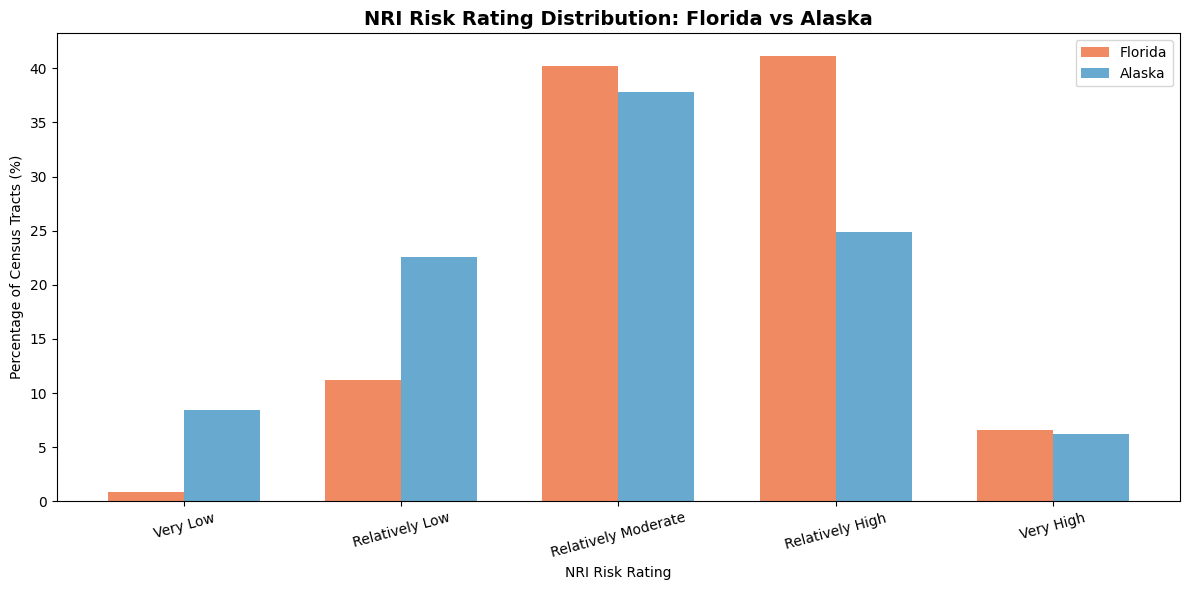

In [52]:
## Figure 1: Side-by-side bar chart of NRI risk ratings as percentages
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]

fl_counts = fl_complete["RISK_RATNG"].value_counts().reindex(rating_order, fill_value=0)
ak_counts = ak_complete["RISK_RATNG"].value_counts().reindex(rating_order, fill_value=0)

fl_pct = fl_counts / fl_counts.sum() * 100
ak_pct = ak_counts / ak_counts.sum() * 100

x = np.arange(len(rating_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, fl_pct, width, label="Florida", color="#ef8a62")
ax.bar(x + width/2, ak_pct, width, label="Alaska", color="#67a9cf")

ax.set_xlabel("NRI Risk Rating")
ax.set_ylabel("Percentage of Census Tracts (%)")
ax.set_title("NRI Risk Rating Distribution: Florida vs Alaska", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rating_order, rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

### Figure 2: Florida - NRI Score vs Custom Score Distribution
Two histograms side by side showing how the NRI risk scores and our custom risk scores are distributed across Florida's census tracts. The shape of each histogram reveals where each method concentrates risk.

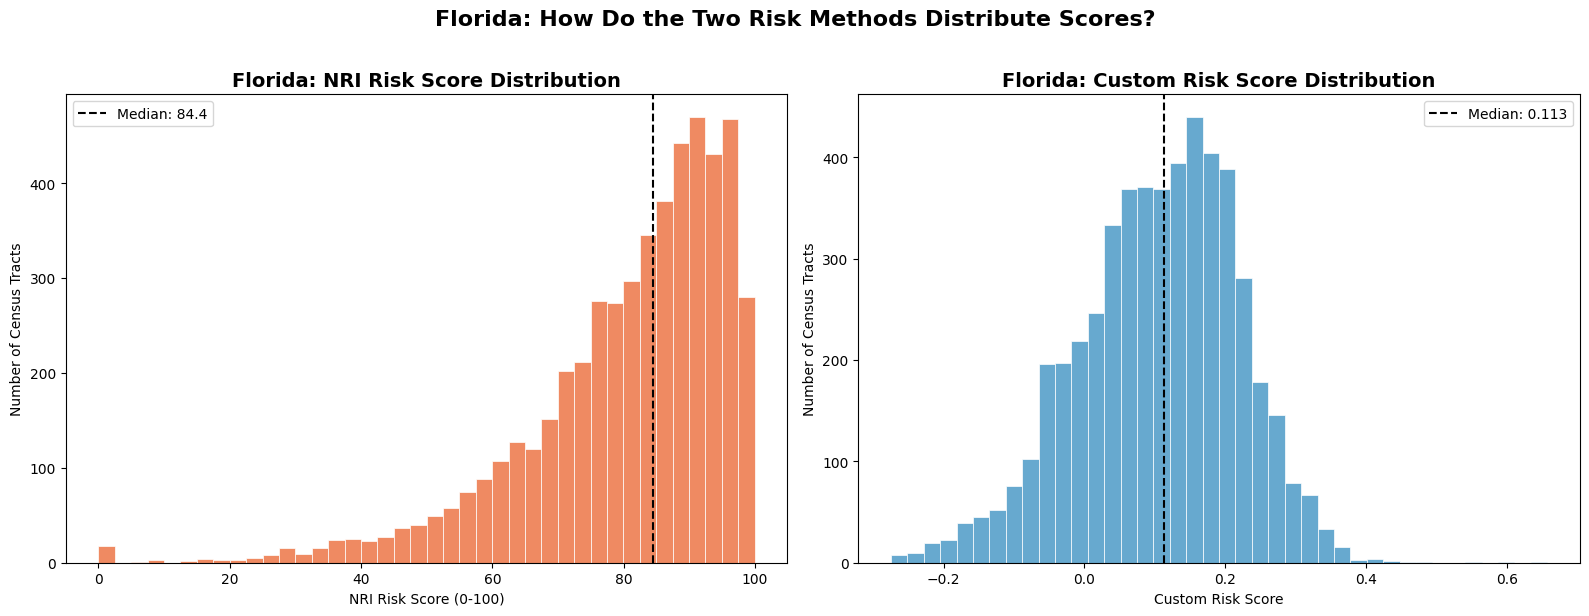

In [53]:
## Figure 2: Florida - NRI vs Custom score distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Left: NRI Risk Score distribution
ax1.hist(fl_complete["RISK_SCORE"].dropna(), bins=40, color="#ef8a62", edgecolor="white", linewidth=0.5)
ax1.set_title("Florida: NRI Risk Score Distribution", fontsize=14, fontweight="bold")
ax1.set_xlabel("NRI Risk Score (0-100)")
ax1.set_ylabel("Number of Census Tracts")
ax1.axvline(fl_complete["RISK_SCORE"].median(), color="black", linestyle="--", linewidth=1.5, label=f'Median: {fl_complete["RISK_SCORE"].median():.1f}')
ax1.legend()

## Right: Custom Risk Score distribution
ax2.hist(fl_complete["CUSTOM_RISK"].dropna(), bins=40, color="#67a9cf", edgecolor="white", linewidth=0.5)
ax2.set_title("Florida: Custom Risk Score Distribution", fontsize=14, fontweight="bold")
ax2.set_xlabel("Custom Risk Score")
ax2.set_ylabel("Number of Census Tracts")
ax2.axvline(fl_complete["CUSTOM_RISK"].median(), color="black", linestyle="--", linewidth=1.5, label=f'Median: {fl_complete["CUSTOM_RISK"].median():.3f}')
ax2.legend()

plt.suptitle("Florida: How Do the Two Risk Methods Distribute Scores?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Figure 3: Alaska - NRI Score vs Custom Score Distribution
Same comparison for Alaska. With only 177 tracts the histograms will be chunkier, but the overall shape still shows how each method distributes risk across the state.

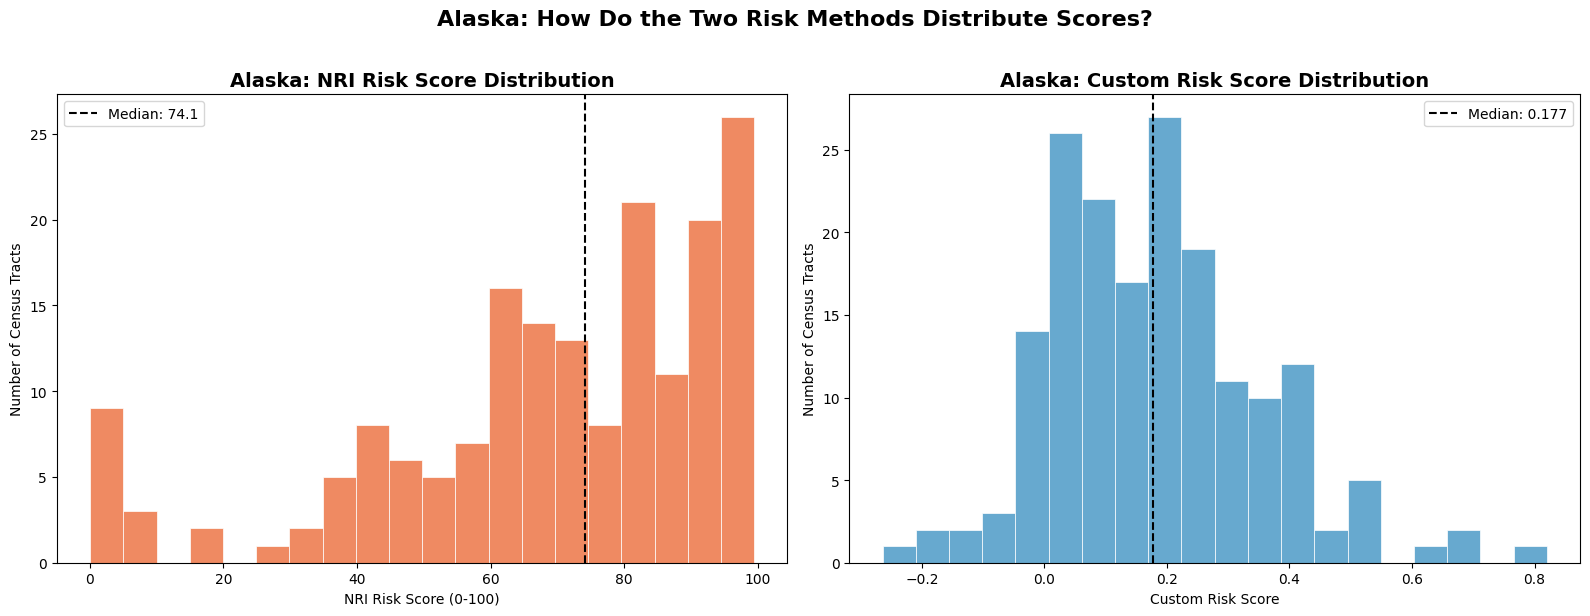

In [54]:
## Figure 3: Alaska - NRI vs Custom score distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Left: NRI Risk Score distribution
ax1.hist(ak_complete["RISK_SCORE"].dropna(), bins=20, color="#ef8a62", edgecolor="white", linewidth=0.5)
ax1.set_title("Alaska: NRI Risk Score Distribution", fontsize=14, fontweight="bold")
ax1.set_xlabel("NRI Risk Score (0-100)")
ax1.set_ylabel("Number of Census Tracts")
ax1.axvline(ak_complete["RISK_SCORE"].median(), color="black", linestyle="--", linewidth=1.5, label=f'Median: {ak_complete["RISK_SCORE"].median():.1f}')
ax1.legend()

## Right: Custom Risk Score distribution
ax2.hist(ak_complete["CUSTOM_RISK"].dropna(), bins=20, color="#67a9cf", edgecolor="white", linewidth=0.5)
ax2.set_title("Alaska: Custom Risk Score Distribution", fontsize=14, fontweight="bold")
ax2.set_xlabel("Custom Risk Score")
ax2.set_ylabel("Number of Census Tracts")
ax2.axvline(ak_complete["CUSTOM_RISK"].median(), color="black", linestyle="--", linewidth=1.5, label=f'Median: {ak_complete["CUSTOM_RISK"].median():.3f}')
ax2.legend()

plt.suptitle("Alaska: How Do the Two Risk Methods Distribute Scores?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Map 1: Florida - NRI Overall Risk Score

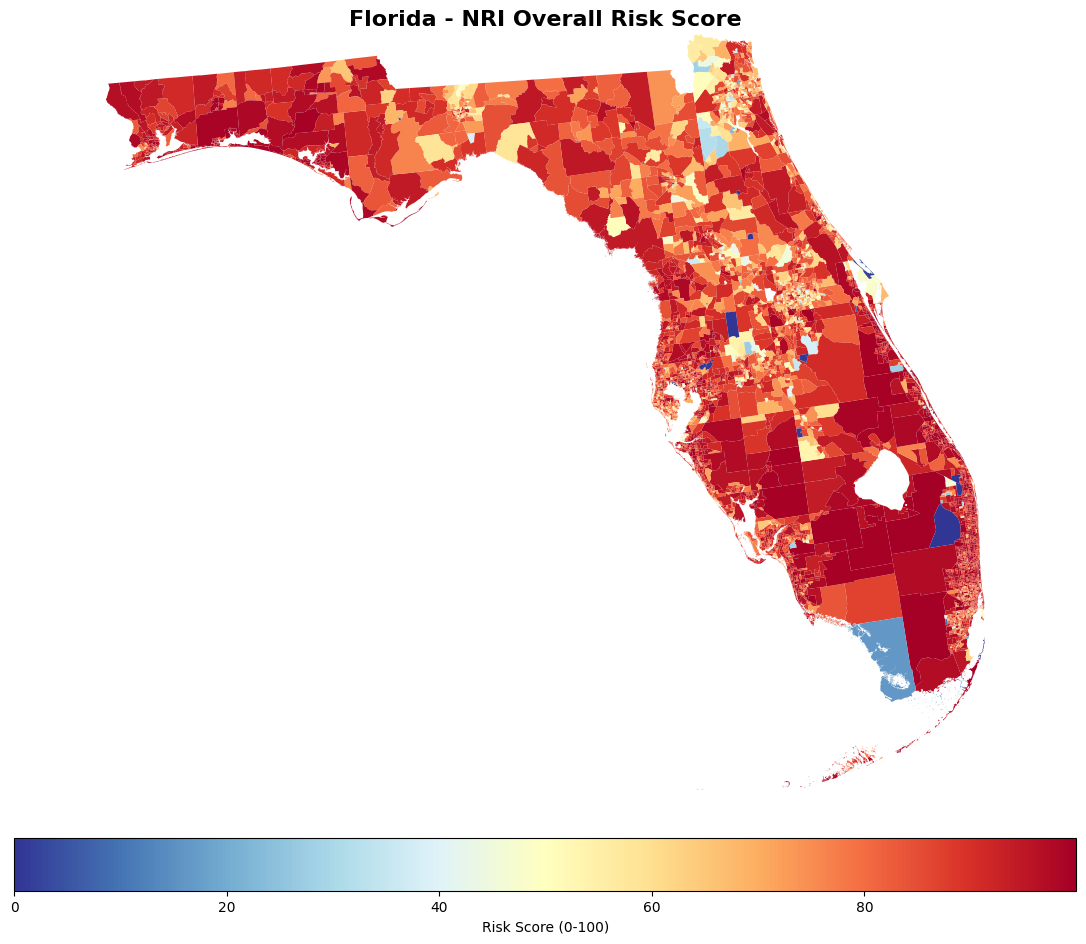

In [55]:
## Map 1: Florida NRI Overall Risk Score
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

state_map.plot(
    column="RISK_SCORE", ax=ax, legend=True, linewidth=0.0, cmap="RdYlBu_r",
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("Florida - NRI Overall Risk Score", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Map 2: Florida - Combined Flood Risk (Coastal + Riverine Average)

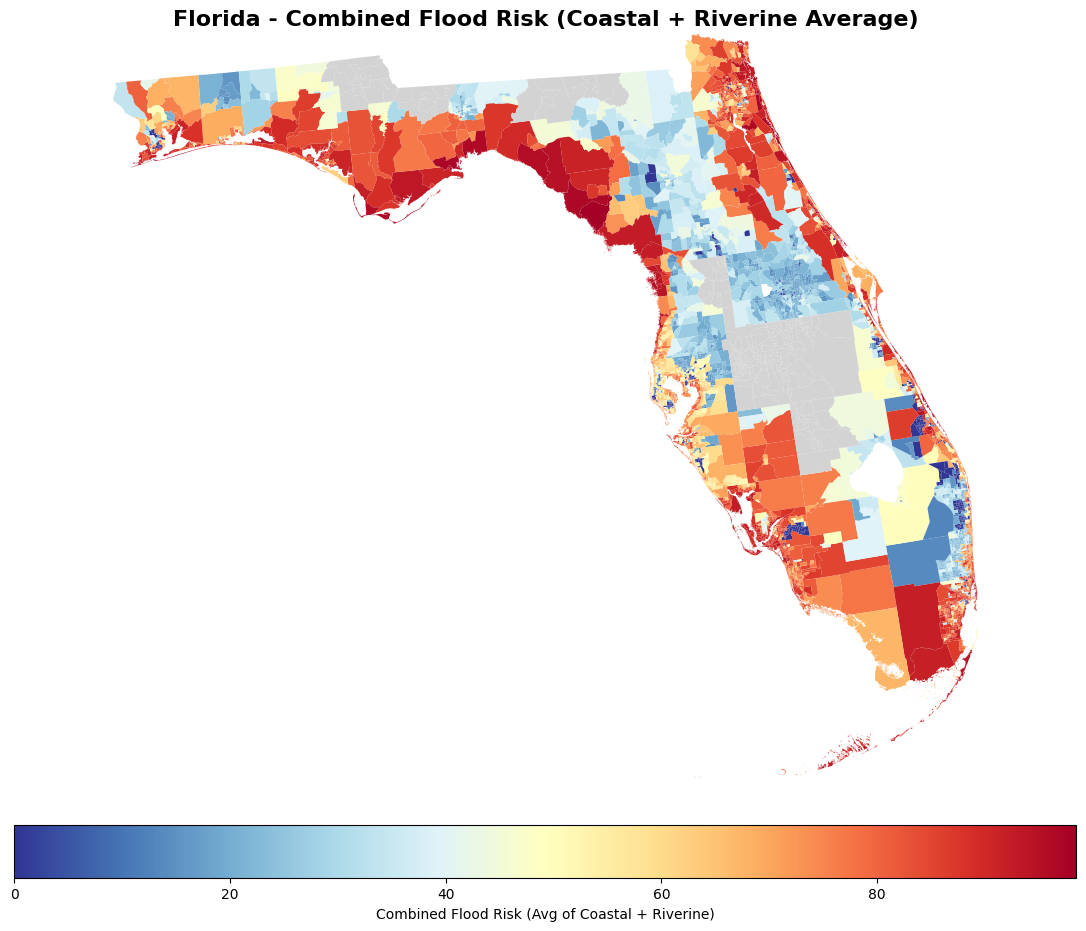

In [56]:
## Map 2: Florida Combined Flood Risk
state_flood = state_map.copy()
state_flood["FLOOD_RISK"] = (state_flood["CFLD_RISKS"] + state_flood["RFLD_RISKS"]) / 2

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

state_flood.plot(
    column="FLOOD_RISK", ax=ax, legend=True, linewidth=0.0, cmap="RdYlBu_r",
    legend_kwds={"label": "Combined Flood Risk (Avg of Coastal + Riverine)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_flood.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("Florida - Combined Flood Risk (Coastal + Riverine Average)", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Map 3: Florida - Wildfire EAL Per Capita

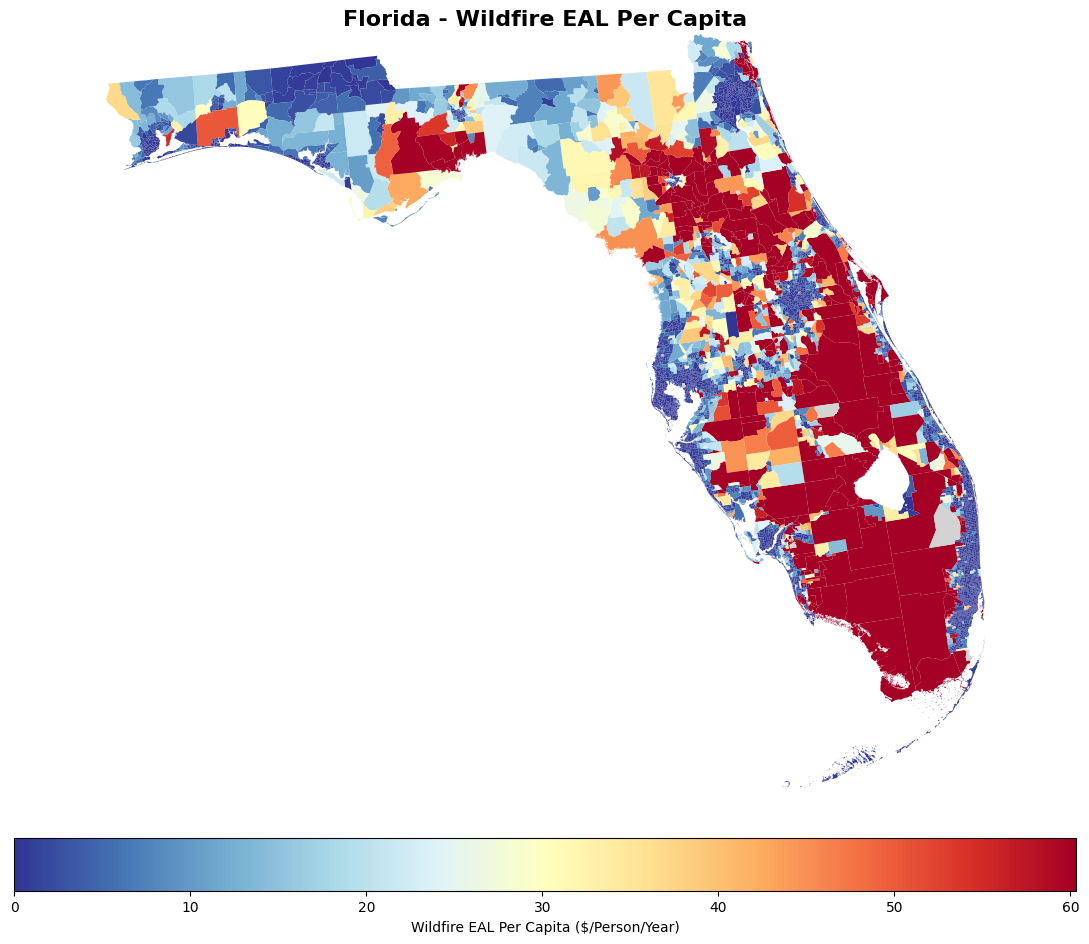

In [57]:
## Map 3: Florida Wildfire EAL Per Capita
state_fire = state_map.copy()

state_fire["WFIR_EAL_PC"] = np.where(
    state_fire["POPULATION"] > 0,
    state_fire["WFIR_EALT"] / state_fire["POPULATION"],
    np.nan
)

## Cap color scale at 95th percentile so outliers don't wash out the map
vmax = state_fire["WFIR_EAL_PC"].quantile(0.95)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

state_fire.plot(
    column="WFIR_EAL_PC", ax=ax, legend=True, linewidth=0.0, cmap="RdYlBu_r",
    vmin=0, vmax=vmax,
    legend_kwds={"label": "Wildfire EAL Per Capita ($/Person/Year)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_fire.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("Florida - Wildfire EAL Per Capita", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Map 4: Florida - Group M Custom Risk Score

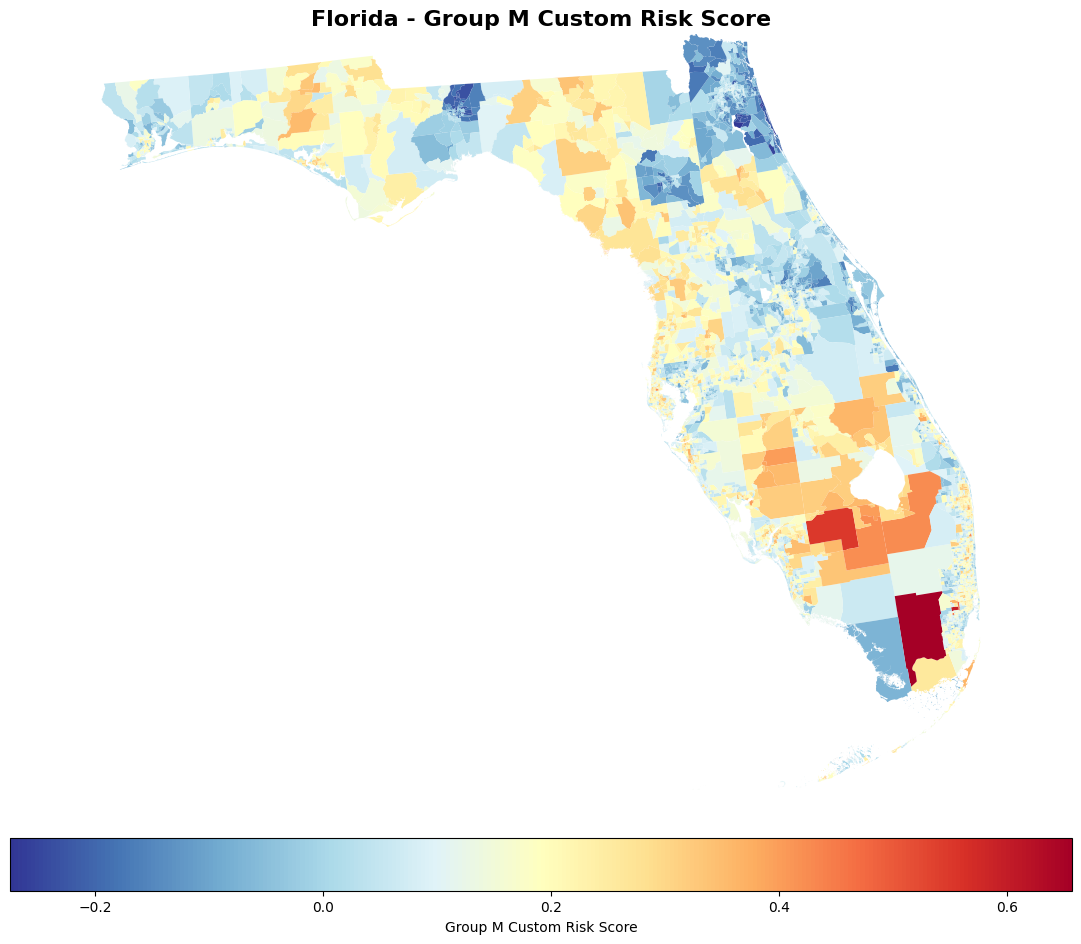

In [58]:
## Map 4: Florida Group M Custom Risk Score
state_calc = state_map.copy()

state_calc["EAL_norm"] = (state_calc["EAL_VALT"] - state_calc["EAL_VALT"].min()) / (state_calc["EAL_VALT"].max() - state_calc["EAL_VALT"].min())
state_calc["SOVI_norm"] = (state_calc["SOVI_SCORE"] - state_calc["SOVI_SCORE"].min()) / (state_calc["SOVI_SCORE"].max() - state_calc["SOVI_SCORE"].min())
state_calc["RESL_norm"] = (state_calc["RESL_SCORE"] - state_calc["RESL_SCORE"].min()) / (state_calc["RESL_SCORE"].max() - state_calc["RESL_SCORE"].min())

state_calc["CUSTOM_RISK"] = (
    (0.5 * state_calc["EAL_norm"])
    + (0.3 * state_calc["SOVI_norm"])
    + (0.2 * state_calc["EAL_norm"] * state_calc["SOVI_norm"])
    - (0.3 * state_calc["RESL_norm"])
)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

state_calc.plot(
    column="CUSTOM_RISK", ax=ax, legend=True, linewidth=0.0, cmap="RdYlBu_r",
    legend_kwds={"label": "Group M Custom Risk Score", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_calc.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("Florida - Group M Custom Risk Score", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 9. Export Cleaned Data
**Requirement 1:** Raw and cleaned data files used in the Python code file.

In [59]:
## Export cleaned and merged datasets
fl_complete.to_csv("Florida_cleaned.csv", index=False)
ak_complete.to_csv("Alaska_cleaned.csv", index=False)
print("Exported Florida_cleaned.csv and Alaska_cleaned.csv")

Exported Florida_cleaned.csv and Alaska_cleaned.csv
